In [1]:
##İMPORTLAR

In [3]:
import numpy as np 
import pandas as pd 
from sklearn.linear_model import Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split 
from sklearn import model_selection
import matplotlib.pyplot as plt 
from sklearn.linear_model import RidgeCV


In [4]:
df=pd.read_excel("Hitters.xlsx")


In [4]:
import ipynbname

try:
    # Notebook dosyasının tam yolunu al
    notebook_path = ipynbname.path()
    print("Notebook dosyasının tam yolu:", notebook_path)
except Exception as e:
    print("Hata:", str(e))



Notebook dosyasının tam yolu: C:\Users\User\makine_öğrenmesi.ipynb


In [6]:
df=pd.read_excel("Hitters.xlsx")
df=df.dropna()
dns=pd.get_dummies(df[["League","Division","NewLeague"]])
y=df["Salary"]
X_=df.drop(['Salary','League','Division','NewLeague'],axis=1).astype('float64')
X=pd.concat([X_,dns[['League_N','Division_W','NewLeague_N']]],axis=1)

In [ ]:
#model kurulumu

In [55]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=99)
from sklearn.linear_model import LinearRegression
y_train.iloc[1]=500;
lm=LinearRegression()
model=lm.fit(X_train,y_train)
y_pred=pd.DataFrame(model.predict(X_train)[0:30])
y_gercek=y_train.iloc[0:30].reset_index(drop=True)
hata=pd.concat([y_gercek,y_pred],axis=1)
hata

,Salary,0
0,595.0,-87223.823409
1,500.0,-43732.162789
2,450.0,24922.905981
3,1300.0,159460.234203
4,587.5,33332.971944
5,155.0,-60308.768327
6,225.0,9472.963431
7,135.0,123832.797589
8,1670.0,126600.402627
9,525.0,187274.200635


In [56]:
#mse ve rmse değerlerinin hesabi

In [57]:
from sklearn.metrics import mean_squared_error
MSE=mean_squared_error(y_train,model.predict(X_train))
RMSE=np.sqrt(MSE)
print(MSE)
print(RMSE)

52949733206.27106
230108.09026688102


In [58]:
#cros_val

In [59]:
from sklearn.model_selection import cross_val_score
cross_val_score(model,X_train,y_train,cv=10,scoring="neg_mean_squared_error")
print(np.mean(-cross_val_score(model,X_train,y_train,cv=10,scoring="neg_mean_squared_error")))

74785374203.07416


In [60]:
print(X_train.dtypes)
print(y_train.dtypes)
print(X_train.isnull().sum())
print(y_train.isnull().sum())

AtBat          float64
Hits           float64
HmRun          float64
Runs           float64
RBI            float64
Walks          float64
Years          float64
CAtBat         float64
CHits          float64
CHmRun         float64
CRuns          float64
CRBI           float64
CWalks         float64
PutOuts        float64
Assists        float64
Errors         float64
League_N          bool
Division_W        bool
NewLeague_N       bool
dtype: object
float64
AtBat          0
Hits           0
HmRun          0
Runs           0
RBI            0
Walks          0
Years          0
CAtBat         0
CHits          0
CHmRun         0
CRuns          0
CRBI           0
CWalks         0
PutOuts        0
Assists        0
Errors         0
League_N       0
Division_W     0
NewLeague_N    0
dtype: int64
0


In [61]:
import statsmodels.api as sm
# Boolean sütunları float türüne dönüştürme
X_train = X_train.astype(float)
X_train_const = sm.add_constant(X_train)
lm=sm.OLS(y_train,X_train_const)
model=lm.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     2.277
Date:                Thu, 23 Jan 2025   Prob (F-statistic):            0.00280
Time:                        01:49:41   Log-Likelihood:                -2711.8
No. Observations:                 197   AIC:                             5464.
Df Residuals:                     177   BIC:                             5529.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        9.155e+04   8.15e+04      1.123      0.263   -6.94e+04    2.52e+05
AtBat         620.2071    609.271      1.018      0.310    -582.163    1822.577
Hits        -5698.8917   2238.769     -2.546      0.012   -1.01e+04   -1280.776
HmRun       -4851.6432   5516.572     -0.879      0.380   -1.57e+04    6035.075
Runs         3481.8884   2655.178      1.311      0.191   -1757.992    8721.769
RBI          3288.4602   2276.344      1.445      0.150   -1203.807    7780.727
Walks       -1717.8810   1741.433     -0.986      0.325   -5154.524    1718.762
Years       -1663.1643   1.12e+04     -0.148      0.882   -2.38e+04    2.05e+04
CAtBat       -333.6274    138.788     -2.404      0.017    -607.519     -59.736
CHits        1792.8252    710.733      2.523      0.013     390.225    3195.425
CHmRun       3372.0035   1537.260      2.194      0.030     338.288    6405.720
CRuns        -669.4072    708.448     -0.945      0.346   -2067.498     728.684
CRBI        -1105.9402    699.027     -1.582      0.115   -2485.441     273.560
CWalks         71.5204    336.509      0.213      0.832    -592.565     735.606
PutOuts       210.5518     72.131      2.919      0.004      68.205     352.898
Assists       417.6373    196.623      2.124      0.035      29.610     805.664
Errors      -6032.4332   3852.907     -1.566      0.119   -1.36e+04    1571.115
League_N     4.226e+04   6.74e+04      0.627      0.532   -9.08e+04    1.75e+05
Division_W  -6.599e+04   3.68e+04     -1.795      0.074   -1.39e+05    6552.208
NewLeague_N  3.851e+04   6.69e+04      0.575      0.566   -9.36e+04    1.71e+05
==============================================================================
Omnibus:                      222.524   Durbin-Watson:                   1.959
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7633.494
Skew:                           4.546   Prob(JB):                         0.00
Kurtosis:                      32.109   Cond. No.                     1.90e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.9e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [64]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=99)
from sklearn.linear_model import LinearRegression
y_train.iloc[1]=500;
lm=LinearRegression()
model=lm.fit(X_train,y_train)
y_pred=pd.DataFrame(model.predict(X_train)[0:30])
y_gercek=y_train.iloc[0:30].reset_index(drop=True)
hata=pd.concat([y_gercek,y_pred],axis=1)
hata

,Salary,0
0,595.0,-87223.823409
1,500.0,-43732.162789
2,450.0,24922.905981
3,1300.0,159460.234203
4,587.5,33332.971944
5,155.0,-60308.768327
6,225.0,9472.963431
7,135.0,123832.797589
8,1670.0,126600.402627
9,525.0,187274.200635


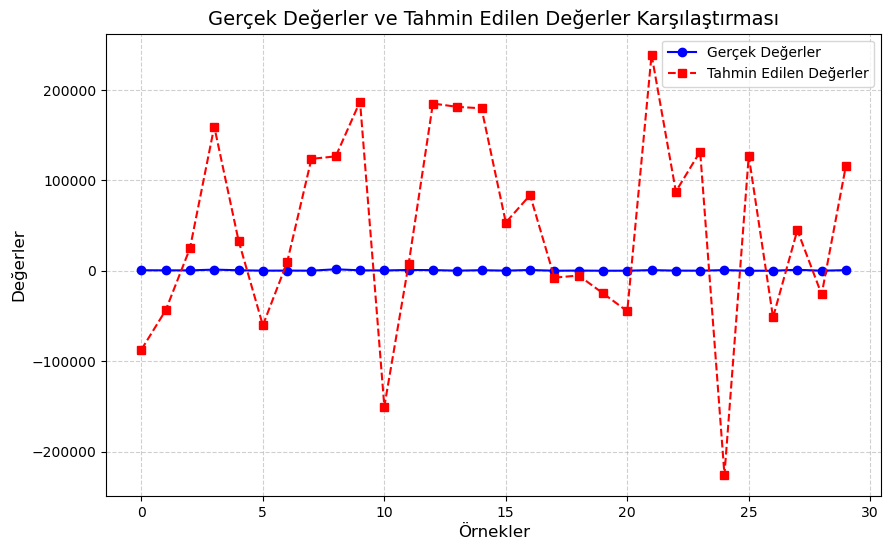

In [65]:
import matplotlib.pyplot as plt

# Görselleştirme için uygun bir veri çerçevesi oluşturma
hata.columns = ["Gerçek", "Tahmin"]  # Sütunlara isim veriyoruz

# Görselleştirme
plt.figure(figsize=(10, 6))

# Gerçek değerler
plt.plot(hata.index, hata["Gerçek"], label="Gerçek Değerler", marker='o', linestyle='-', color='b')

# Tahmin edilen değerler
plt.plot(hata.index, hata["Tahmin"], label="Tahmin Edilen Değerler", marker='s', linestyle='--', color='r')

# Grafiğin başlık ve etiketleri
plt.title("Gerçek Değerler ve Tahmin Edilen Değerler Karşılaştırması", fontsize=14)
plt.xlabel("Örnekler", fontsize=12)
plt.ylabel("Değerler", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Grafiği gösterme
plt.show()
